In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const
import seaborn as sns
import glob
from set_rcParams import set_rcParams, set_tick_font
from sklearn.linear_model import LinearRegression
# print(plt.rcParams.keys())
set_rcParams(presentation=True)
palette = sns.color_palette("colorblind")

In [5]:
# mean speed of the distribution
def v_mean(T,m):
  return 2 / np.sqrt(np.pi) * np.sqrt( 2 * const.R.value * T / (m * const.N_A.value) )

def v_rel_mean(T, m):
  return np.sqrt(2) * v_mean

In [6]:
m = 6.6e-26
print(v_mean(373, m) * 0.01 / ( 1e6 / 100))

0.0004457528685018763


In [7]:
def calc_nu_ab(m_a, m_b, sigma_0, n):
  M = m_a + m_b
  m_ab = m_a * m_b / M
  return m_ab / (m_a + m_b) * 3 * n * sigma_0

def T_alpha_func(nu_ab, t):
  return 550 + 450 * np.exp(-4/3 * nu_ab * t)

def T_beta_func(nu_ab, t):
  return 550 - 450 * np.exp(-4/3 * nu_ab * t)

m = 6.646764e-27
m_a = m
m_b = m
sigma_0 = 1e-21
n = 1e25
nu_ab = calc_nu_ab(m_a, m_b, sigma_0, n)

inv_freq = 1 / nu_ab
h = 1e-2 / 4
delta_t = 1e-7
freq_res = delta_t / inv_freq

print(f"{inv_freq:0.5E} sec")
print(f"{freq_res:0.5E} res")
print( (v_mean(1000, m) * delta_t) / h)
print( (v_mean(100, m) * delta_t)  / h)


t = np.arange(1, 101, 1) * delta_t

T_alpha_analytic = T_alpha_func(nu_ab, t)
T_beta_analytic = T_beta_func(nu_ab, t)

data = pd.read_csv("testing_out.csv")
# print(data["time"])
# print(t)

1.33333E-04 sec
7.50000E-04 res
0.09199549495019274
0.029091529851712743


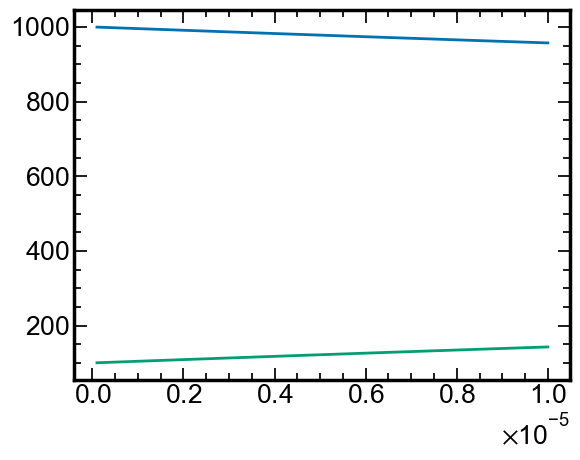

In [8]:
plt.figure()
plt.plot(t, T_alpha_analytic)
plt.plot(t, T_beta_analytic)
plt.plot(data["time"][1:], data["T_alpha"][1:])
plt.plot(data["time"][1:], data["T_beta"][1:])
plt.show()

# print(np.linalg.norm(T_alpha_analytic - data["T_alpha"][1:]) / np.linalg.norm(T_alpha_analytic))
# print(np.linalg.norm(T_beta_analytic - data["T_beta"][1:]) / np.linalg.norm(T_beta_analytic))

Using a seed value of 0 and then moving the initial temperature for to get a better initial temp 

In [9]:
ppe = [5, 10, 20, 40, 80, 160]
T_alpha_0 = [1444, 1004, 1127, 1055, 1045,  973]
T_beta_0 = [145, 101, 113, 106, 105, 98]

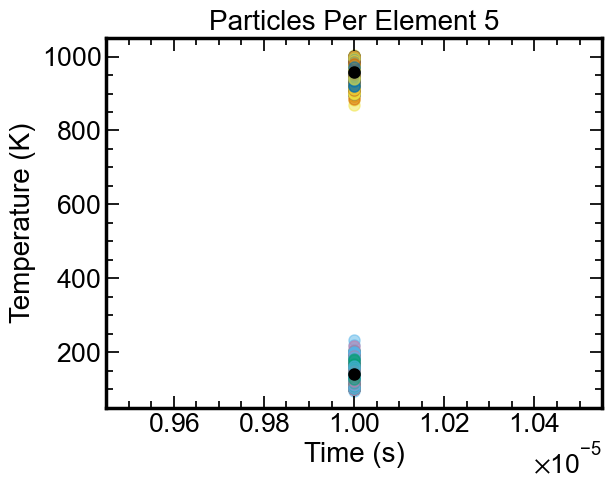

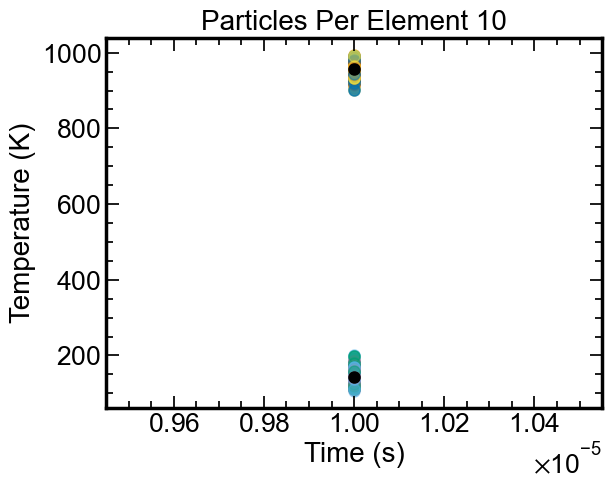

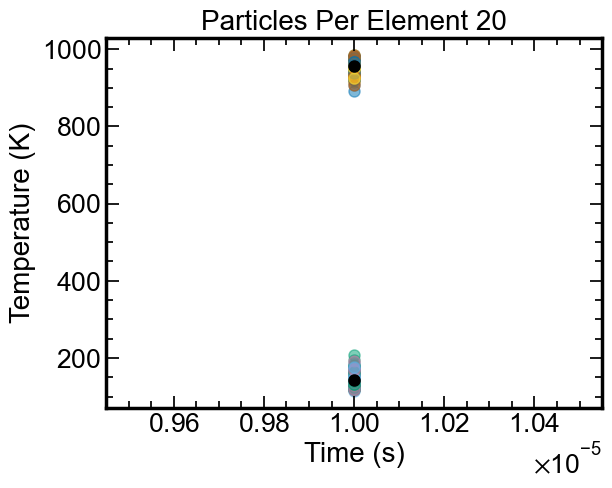

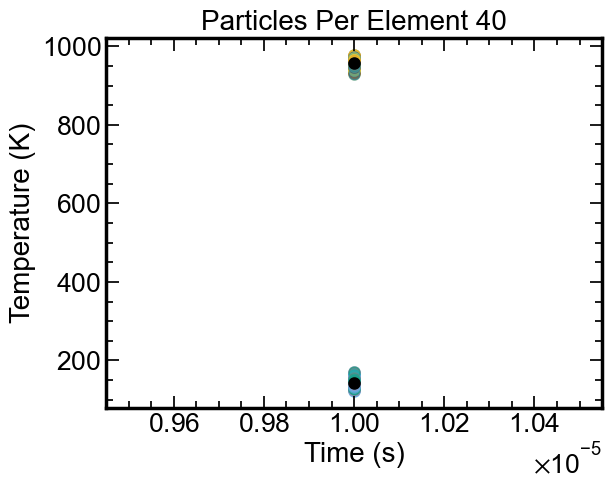

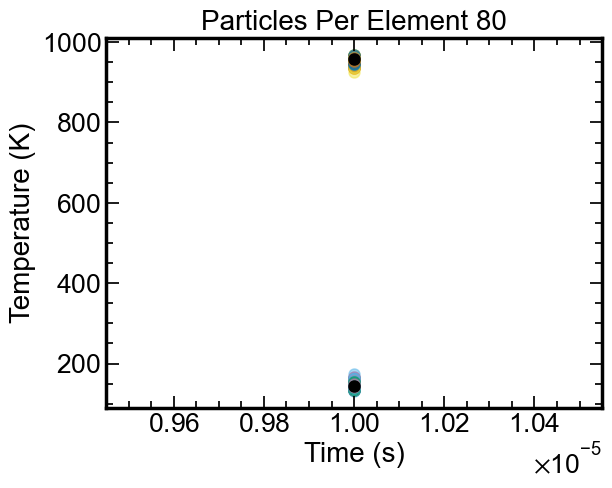

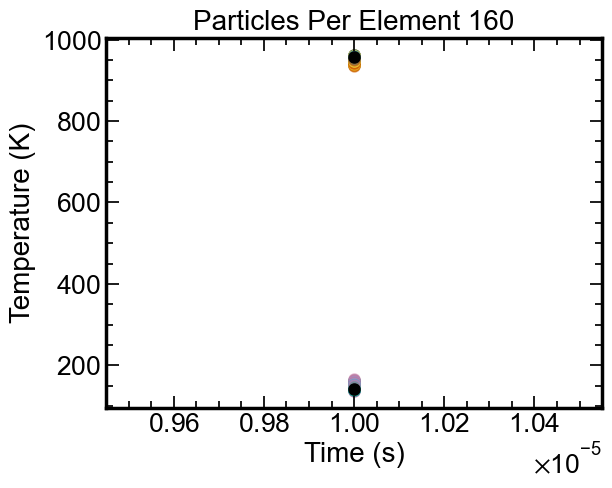

In [21]:
min_ppe = 5
runs = 6

alpha_errors = []
beta_errors = []
alpha_stds = []
beta_stds = []
ppes = []
for i in range(runs):
  ppe = int(min_ppe * 2**i)
  ppes.append(ppe)

  folder = f"{ppe:d}_ppe/"
  files = sorted(glob.glob(folder + "*.csv"))[:-4]
  time = None
  T_alpha = None
  alpha_error = []
  T_alpha_vals = []
  T_beta_vals = []
  T_beta = None
  beta_error = []

  plt.figure()
  for j, f in enumerate(files[1:1000]):
      data = pd.read_csv(f)
      # print(f)
      if j == 0:
          time = data["time"].to_numpy()[1:]
          # print(len(time))
          T_alpha_analytic = T_alpha_func(nu_ab, time)
          T_beta_analytic = T_beta_func(nu_ab, time)


      T_alpha = data["T_alpha"].to_numpy()[1:]
      T_beta = data["T_beta"].to_numpy()[1:]
      if (len(T_alpha) != 100):
        # print("skipping")
        continue
      plt.scatter(time[-1], T_alpha[-1], alpha=0.5)
      plt.scatter(time[-1], T_beta[-1], alpha=0.5)

      # T_alpha_vals.append(T_alpha[-1])
      # T_beta_vals.append(T_beta[-1])

      # alpha_error.append(np.linalg.norm(T_alpha_analytic - T_alpha, ord=2) / np.linalg.norm(T_alpha_analytic, ord=2))
      # beta_error.append(np.linalg.norm(T_beta_analytic - T_beta, ord=2) / np.linalg.norm(T_beta_analytic, ord=2))

      # alpha_error.append(np.abs(T_alpha_analytic[-1] - T_alpha[-1]) / T_alpha_analytic[-1])
      # beta_error.append(np.abs(T_beta_analytic[-1] - T_beta[-1]) / T_beta_analytic[-1])
  plt.plot(time[-1], T_alpha_analytic[-1], 'ko')
  plt.plot(time[-1], T_beta_analytic[-1], 'ko')
  plt.title(f"Particles Per Element {ppe:d}")
  plt.xlabel(f"Time (s)")
  plt.ylabel(f"Temperature (K)")
  plt.show()


  # T_alpha_vals = np.array(T_alpha_vals)
  # T_beta_vals = np.array(T_beta_vals)
  # # alpha_error = np.array(alpha_error)
  # # beta_error = np.array(beta_error)

  # alpha_errors.append(abs(T_alpha_vals.mean() -  T_alpha_analytic[-1]) / T_alpha_analytic[-1])
  # beta_errors.append(abs(T_beta_vals.mean() -  T_beta_analytic[-1]) / T_beta_analytic[-1])
  # alpha_stds.append(alpha_error.std())
  # beta_errors.append(beta_error.mean())
  # beta_stds.append(beta_error.std())

#      if i == 0:
#          time = data["time"].to_numpy()[1:]
#          T_alpha = data["T_alpha"].to_numpy()[1:]
#          T_beta = data["T_beta"].to_numpy()[1:]
#          alpha_error.append(T_alpha - T_alpha_func(nu_ab, time))
#      else:
#          T_alpha = np.vstack((T_alpha,  data["T_alpha"].to_numpy()[1:] ))
#          T_beta = np.vstack((T_beta,  data["T_beta"].to_numpy()[1:] ))
#
#
#  mean_T_alpha = T_alpha.mean(axis=0)
#  std_T_alpha = T_alpha.std(axis=0)
#  mean_T_beta = T_beta.mean(axis=0)
#  std_T_beta = T_beta.std(axis=0)

  # plt.figure()
  # # plt.plot(t, T_alpha_analytic)
  # # plt.plot(t, T_beta_analytic)
  # plt.plot(time, mean_T_alpha)
  # plt.plot(time, mean_T_beta)
  # plt.fill_between(time, mean_T_alpha - 2 * std_T_alpha, mean_T_alpha + 2 * std_T_alpha, alpha=0.5)
  # plt.fill_between(time, mean_T_beta - 2 * std_T_beta, mean_T_beta + 2 * std_T_beta, alpha=0.5)

#  print(np.linalg.norm(T_alpha_func(nu_ab, time) - T_alpha.mean(axis=0)))
#


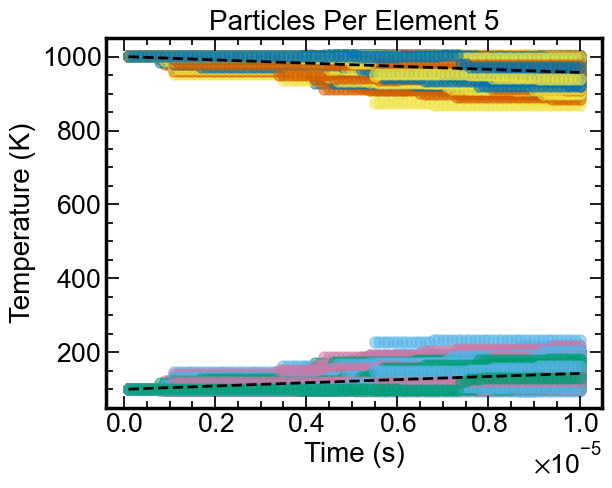

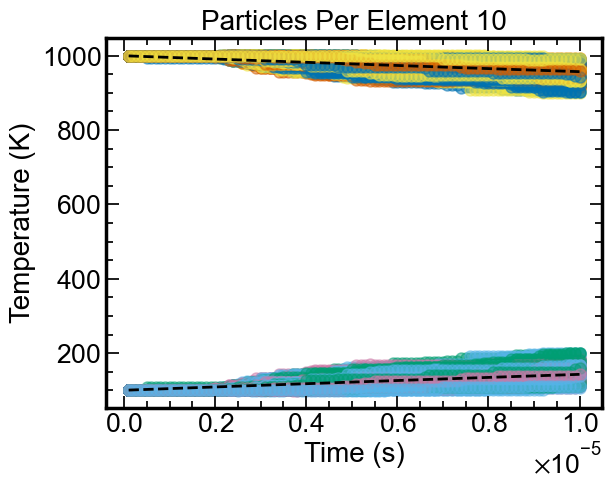

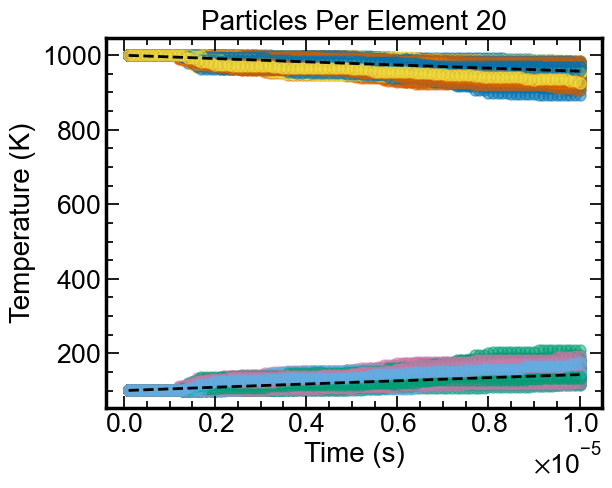

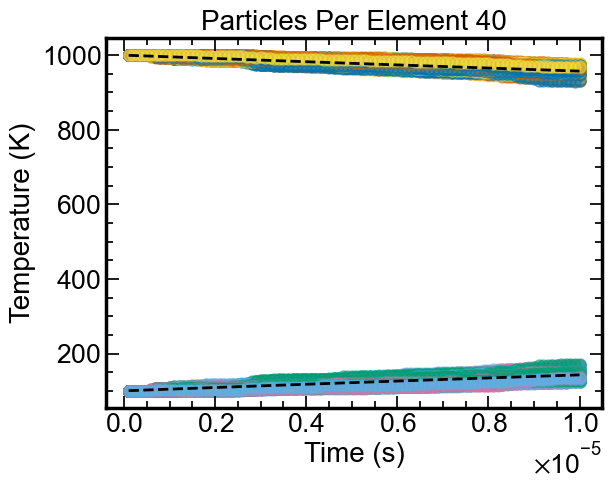

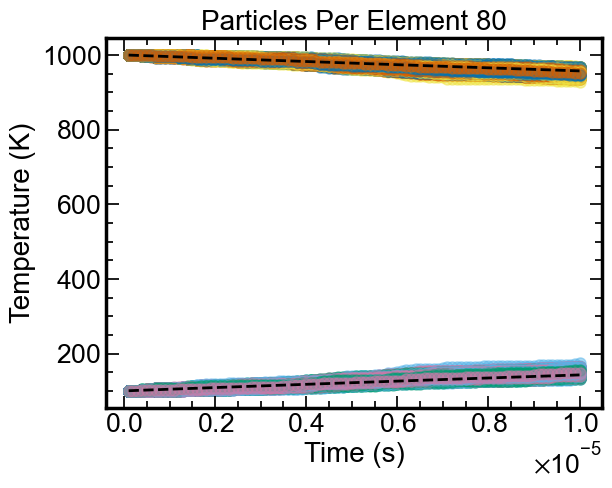

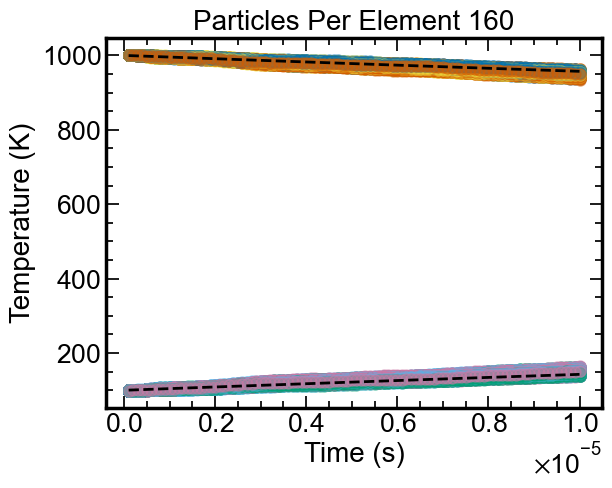

In [20]:
min_ppe = 5
runs = 6

alpha_errors = []
beta_errors = []
alpha_stds = []
beta_stds = []
ppes = []
for i in range(runs):
  ppe = int(min_ppe * 2**i)
  ppes.append(ppe)

  folder = f"{ppe:d}_ppe/"
  files = sorted(glob.glob(folder + "*.csv"))[:-4]
  time = None
  T_alpha = None
  alpha_error = []
  T_alpha_vals = []
  T_beta_vals = []
  T_beta = None
  beta_error = []

  plt.figure()
  for j, f in enumerate(files[1:1000]):
      data = pd.read_csv(f)
      if j == 0:
          time = data["time"].to_numpy()[1:]
          T_alpha_analytic = T_alpha_func(nu_ab, time)
          T_beta_analytic = T_beta_func(nu_ab, time)


      T_alpha = data["T_alpha"].to_numpy()[1:]
      T_beta = data["T_beta"].to_numpy()[1:]
      if (len(T_alpha) != 100):
        continue
      plt.scatter(time, T_alpha, alpha=0.5)
      plt.scatter(time, T_beta, alpha=0.5)

  plt.plot(time, T_alpha_analytic, 'k--')
  plt.plot(time, T_beta_analytic, 'k--')
  plt.title(f"Particles Per Element {ppe:d}")
  plt.xlabel(f"Time (s)")
  plt.ylabel(f"Temperature (K)")
  plt.show()


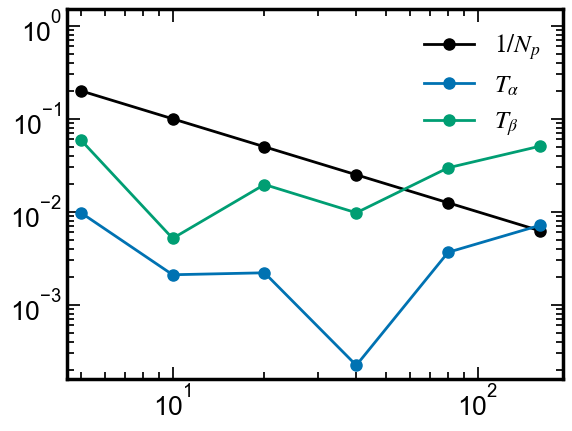

In [11]:
plt.figure()
# plt.loglog(ppes, 1 / np.array(ppes) - 1 / np.array(ppes)[0] + alpha_errors[0], 'k-o')
plt.loglog(ppes, 1 / np.array(ppes), 'k-o', label='$1/N_p$')
# plt.errorbar(ppes, beta_errors, yerr=2 * np.array(beta_stds) ,fmt='-o', label='beta')
# plt.errorbar(ppes, alpha_errors, yerr=2 * np.array(alpha_stds) ,fmt='-o', label='alpha')
plt.plot(ppes, alpha_errors, '-o', label='$T_\\alpha$')
plt.plot(ppes, beta_errors, '-o',  label='$T_\\beta$')
# plt.loglog(ppes, beta_errors, '-o', label='beta')
plt.xlim(left=4.5)
plt.ylim(top=1.5)
plt.legend(loc='upper right')
plt.show()

# plt.figure()
# # plt.loglog(ppes, 1 / np.array(ppes) - 1 / np.array(ppes)[0] + alpha_errors[0], 'k-o')
# plt.plot(ppes, 1 / np.array(ppes), 'k-o', label='$1/\\sqrt{N_p}$')
# plt.errorbar(ppes, beta_errors, yerr=2 * np.array(beta_stds) ,fmt='-o', label='beta')
# plt.errorbar(ppes, alpha_errors, yerr=2 * np.array(alpha_stds) ,fmt='-o', label='alpha')
# # plt.loglog(ppes, beta_errors, '-o', label='beta')
# plt.xlim(left=0)
# plt.ylim(top=1.5)
# plt.legend()
# plt.show()